In [29]:
from pathlib import Path
import re
from collections import Counter, defaultdict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

try:
    import PyPDF2
except Exception as e:
    raise ImportError("PyPDF2 tidak ditemukan. Jalankan: pip install PyPDF2") from e

sns.set_theme(style="whitegrid")
VOWELS = set("aeiou")

pdf_path = Path("ARTIKEL TUGAS PENGGANTI ETS MATDIS_24083010006.pdf")
if not pdf_path.exists():
    raise FileNotFoundError(f"File PDF tidak ditemukan: {pdf_path}")

# baca seluruh teks PDF
reader = PyPDF2.PdfReader(open(pdf_path, "rb"))
pages = []
for p in reader.pages:
    pages.append(p.extract_text() or "")
text = "\n".join(pages)

# fungsi pembantu
def ambil_bagian(teks, start_patterns, end_patterns):
    """Ambil teks dari first occurrence start_patterns sampai tepat sebelum first occurrence end_patterns."""
    start_re = "(" + "|".join(map(re.escape, start_patterns)) + ")"
    end_re = "(" + "|".join(map(re.escape, end_patterns)) + ")"
    m1 = re.search(start_re, teks, re.IGNORECASE)
    if not m1:
        return ""
    start_idx = m1.end()
    m2 = re.search(end_re, teks[start_idx:], re.IGNORECASE)
    end_idx = (m2.start() + start_idx) if m2 else len(teks)
    return teks[start_idx:end_idx].strip()

def tokenize_words(teks):
    return re.findall(r"[A-Za-zÀ-ÖØ-öø-ÿ]+", teks)

def count_vc(word):
    w = word.lower()
    v = sum(1 for ch in w if ch in VOWELS)
    c = sum(1 for ch in w if ch.isalpha() and ch not in VOWELS)
    return v, c

def split_sentences(teks):
    # split on sentence-ending punctuation; more permissive (does not require capital next)
    parts = re.split(r'(?<=[.!?])\s+', teks)
    return [p.strip() for p in parts if p.strip()]

def split_paragraphs(teks):
    parts = re.split(r'\n{2,}', teks)
    # fallback: if no double-newline paragraphs, try splitting on single newline lines that are long
    parts = [p.strip() for p in parts if p.strip()]
    return parts

abstrak = ambil_bagian(text, ["Abstrak", "Abstract"], ["Pendahuluan", "Introduction"])
pendahuluan = ambil_bagian(text, ["Pendahuluan", "Introduction"], ["Kesimpulan", "Conclusion", "Simpulan"])
kesimpulan = ambil_bagian(text, ["Kesimpulan", "Conclusion", "Simpulan"], ["Daftar Pustaka", "References"])

print("EXTRACTED:")
print(f"- Abstrak: {len(abstrak.split())} kata")
print(f"- Pendahuluan: {len(pendahuluan.split())} kata")
print(f"- Kesimpulan: {len(kesimpulan.split())} kata")

EXTRACTED:
- Abstrak: 280 kata
- Pendahuluan: 2078 kata
- Kesimpulan: 138 kata



CUPLIKAN (Abstrak):
--------------------------------------------------------------------------------
The phenomenon of Gold and Green Open Access began to grow and develop in Indonesia. There are many
universities in Indonesia that provide institutional repositories to facilitate the dissemination, access, reuse and
preservation of a work produced by the academic community (Green Open Access). Universities also publish
electronic journals with open licenses (Gold Open Access) so as to spur the process of dissemination science
knowledge and accelerate the impact so that published scientific articles can be cited by other scien tific articles.
qualitative method used in this study. This study showed the development of open access and its contribution to the
scientific community in Ind onesia, through the exposure of data both quantitatively and qualitatively on the number
and growth of inst...

SOAL 2: Tabel Pivot (frekuensi) & Tabel Pivot (kata unik)

Tabel Pivot Frekuensi (baris=vokal

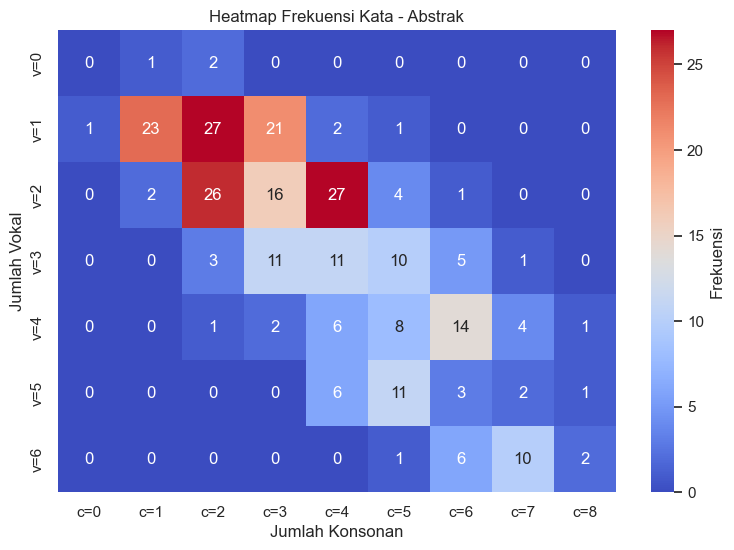

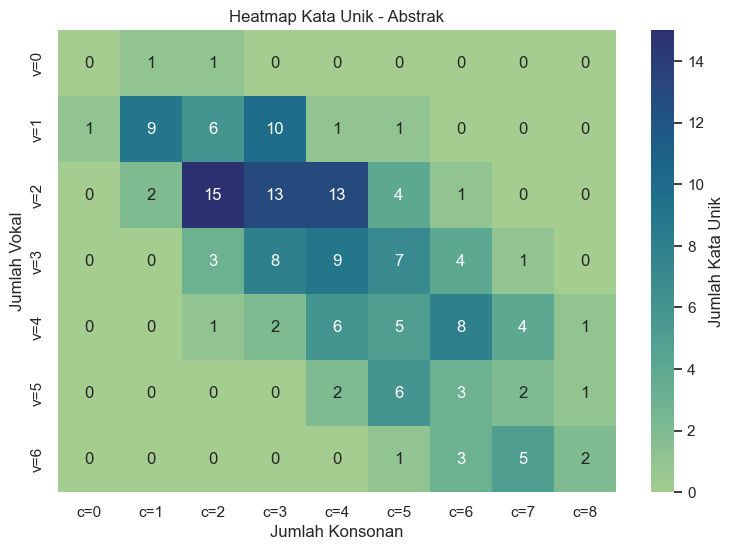


Ringkasan (Soal 2):
- Total kata (token) di Abstrak: 273
- Top kombinasi (vokal,konsonan) menurut frekuensi:
   v=1, c=2  => frekuensi=27, kata unik=6
   v=2, c=4  => frekuensi=27, kata unik=13
   v=2, c=2  => frekuensi=26, kata unik=15
   v=1, c=1  => frekuensi=23, kata unik=9
   v=1, c=3  => frekuensi=21, kata unik=10
   v=2, c=3  => frekuensi=16, kata unik=13

SOAL 3: Jumlah kata dalam setiap kalimat
Kalimat 1: 15 kata
Kalimat 2: 29 kata
Kalimat 3: 38 kata
Kalimat 4: 6 kata
Kalimat 5: 38 kata
Kalimat 6: 0 kata
Kalimat 7: 20 kata
Kalimat 8: 40 kata
Kalimat 9: 41 kata
Kalimat 10: 8 kata
Kalimat 11: 30 kata
Kalimat 12: 8 kata


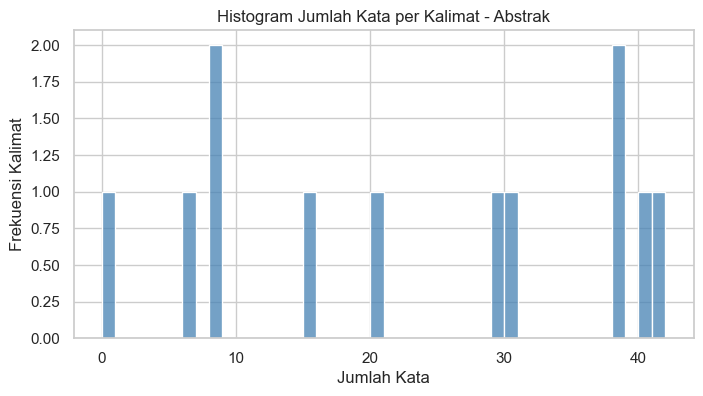


SOAL 4: Jumlah kalimat dalam setiap paragraf
Paragraf 1: 12 kalimat


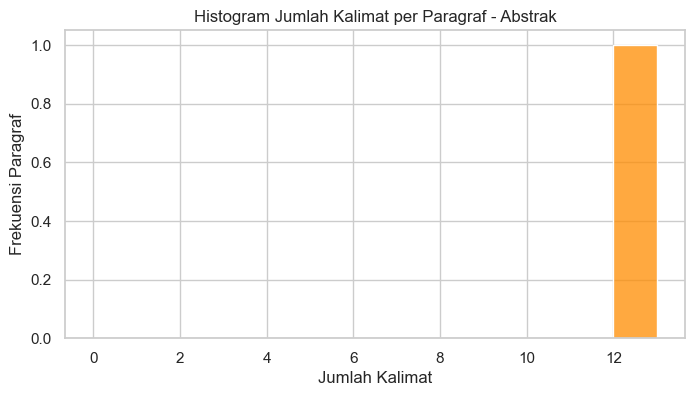

In [39]:
# ANALISIS ABSTRAK

bagian = abstrak
nama = "Abstrak"

print("\n" + "="*80)
print(f"CUPLIKAN ({nama}):")
print("-"*80)
print(bagian[:800] + ("..." if len(bagian)>800 else ""))
print("="*80 + "\n")

# SOAL 2: Pivot konsonan-vokal
print("SOAL 2: Tabel Pivot (frekuensi) & Tabel Pivot (kata unik)")
words = tokenize_words(bagian)
pairs = [count_vc(w) for w in words]
freq = Counter(pairs)
unique = defaultdict(set)
for w, vc in zip(words, pairs):
    unique[vc].add(w.lower())
unique_count = {k: len(s) for k, s in unique.items()}

if pairs:
    max_v = max(v for v,c in pairs)
    max_c = max(c for v,c in pairs)
else:
    max_v = max_c = 0

# build grids and labeled DataFrames
freq_grid = np.zeros((max_v+1, max_c+1), dtype=int)
uniq_grid = np.zeros((max_v+1, max_c+1), dtype=int)
for (v,c), f in freq.items():
    freq_grid[v,c] = f
for (v,c), u in unique_count.items():
    uniq_grid[v,c] = u

df_freq = pd.DataFrame(freq_grid, index=[f"v={i}" for i in range(max_v+1)],
                       columns=[f"c={j}" for j in range(max_c+1)])
df_uniq = pd.DataFrame(uniq_grid, index=[f"v={i}" for i in range(max_v+1)],
                       columns=[f"c={j}" for j in range(max_c+1)])

print("\nTabel Pivot Frekuensi (baris=vokal, kolom=konsonan):")
print(df_freq)
print("\nTabel Pivot Jumlah Kata Unik (baris=vokal, kolom=konsonan):")
print(df_uniq)

# Heatmaps
if df_freq.values.sum() > 0:
    plt.figure(figsize=(9,6))
    sns.heatmap(df_freq, annot=True, fmt="d", cmap="coolwarm", cbar_kws={'label':'Frekuensi'})
    plt.title(f"Heatmap Frekuensi Kata - {nama}")
    plt.xlabel("Jumlah Konsonan")
    plt.ylabel("Jumlah Vokal")
    plt.show()
else:
    print("Tidak ada frekuensi untuk diplot (tidak ada kata).")

if df_uniq.values.sum() > 0:
    plt.figure(figsize=(9,6))
    sns.heatmap(df_uniq, annot=True, fmt="d", cmap="crest", cbar_kws={'label':'Jumlah Kata Unik'})
    plt.title(f"Heatmap Kata Unik - {nama}")
    plt.xlabel("Jumlah Konsonan")
    plt.ylabel("Jumlah Vokal")
    plt.show()
else:
    print("Tidak ada data kata unik untuk diplot.")

# Ringkasan frekuensi + cacah
print("\nRingkasan (Soal 2):")
print(f"- Total kata (token) di {nama}: {len(words)}")
if freq:
    print("- Top kombinasi (vokal,konsonan) menurut frekuensi:")
    for (v,c),cnt in freq.most_common(6):
        print(f"   v={v}, c={c}  => frekuensi={cnt}, kata unik={unique_count.get((v,c),0)}")
else:
    print("- Tidak ada kata ditemukan.")

# SOAL 3: Jumlah kata dalam tiap kalimat 
print("\nSOAL 3: Jumlah kata dalam setiap kalimat")
sentences = split_sentences(bagian)
if sentences:
    words_per_sentence = [len(tokenize_words(s)) for s in sentences]
    for i, (s, wc) in enumerate(zip(sentences, words_per_sentence), start=1):
        print(f"Kalimat {i}: {wc} kata")
    # histogram overview
    plt.figure(figsize=(8,4))
    sns.histplot(words_per_sentence, bins=range(0, max(words_per_sentence)+2), kde=False, color="steelblue")
    plt.title(f"Histogram Jumlah Kata per Kalimat - {nama}")
    plt.xlabel("Jumlah Kata")
    plt.ylabel("Frekuensi Kalimat")
    plt.show()
else:
    print("Tidak ada kalimat terdeteksi pada bagian ini.")

# SOAL 4: Jumlah kalimat dalam tiap paragraf 
print("\nSOAL 4: Jumlah kalimat dalam setiap paragraf")
paragraphs = split_paragraphs(bagian)
if paragraphs:
    sentences_per_paragraph = [len(split_sentences(p)) for p in paragraphs]
    for i, sp in enumerate(sentences_per_paragraph, start=1):
        print(f"Paragraf {i}: {sp} kalimat")
    plt.figure(figsize=(8,4))
    sns.histplot(sentences_per_paragraph, bins=range(0, max(sentences_per_paragraph)+2), kde=False, color="darkorange")
    plt.title(f"Histogram Jumlah Kalimat per Paragraf - {nama}")
    plt.xlabel("Jumlah Kalimat")
    plt.ylabel("Frekuensi Paragraf")
    plt.show()
else:
    print("Tidak ada paragraf terdeteksi pada bagian ini.")


CUPLIKAN (Pendahuluan):
--------------------------------------------------------------------------------
Munculnya bentuk neo -kapitalisme dewasa ini berdampak pada kapitalisme ilmu pengetahuan.
Meminjam pemikiran Pierre Bourdieu mengenai modal ( capital), hanya individu yang memiliki modal lah
yang akan memenangkan  arena pertarungan. Jika pada era industri yang diperdagangkan oleh kaum
kapitalis adalah produk (barang atau jasa), kini di era informasi muncul bentuk kapitalisme baru (neo -
kapitalisme) yangmemperdagangkan ide dalam bentuk fisiknya berupa informasi.
Dewasa ini, telah merabak di seantero dunia penerbit ( publisher ) yang berorientasi pada
keuntungan perusahaan ( profit oriented ). Para penerbit tersebut menerbitkan publikasi berupa buku, jurnal,
dan sumber daya informasi lainnya untuk diperjualbelikan kepada masyarakat akademis yang merupakan
94
Copyright ©201 7, ISSN: 2598 -30...

SOAL 2: Tabel Pivot (frekuensi) & Tabel Pivot (kata unik)

Tabel Pivot Frekuensi (baris=v

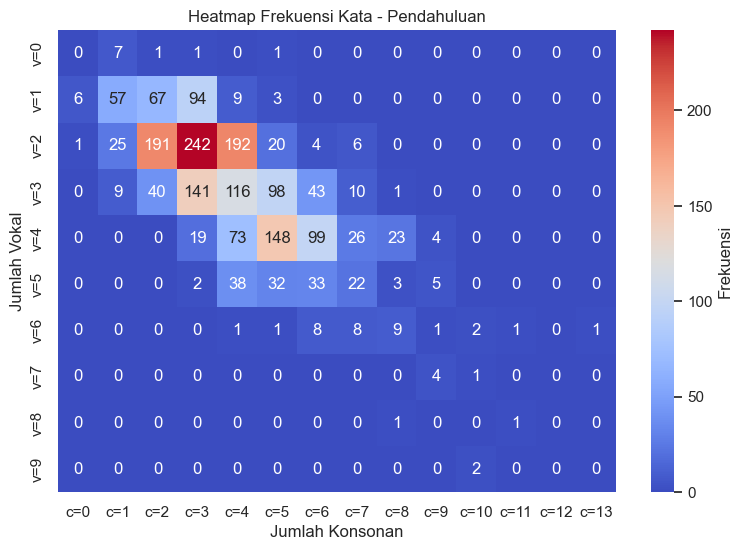

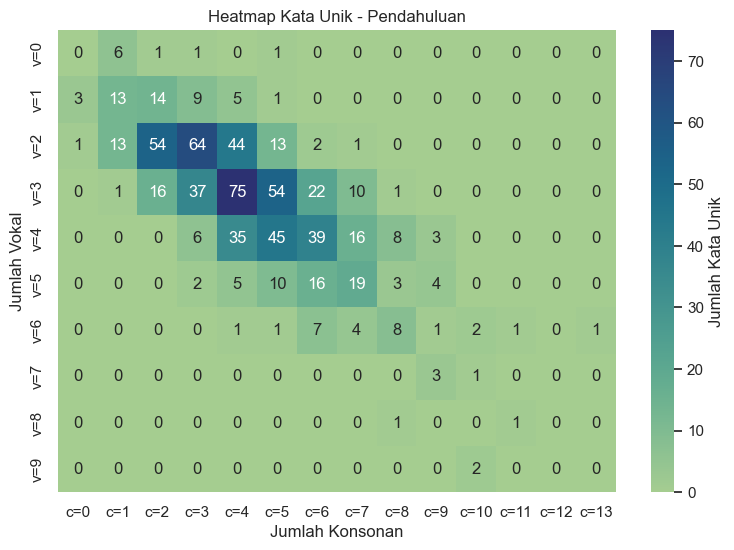


Ringkasan (Soal 2):
- Total kata (token) di Pendahuluan: 1953
- Top kombinasi (vokal,konsonan) menurut frekuensi:
   v=2, c=3  => frekuensi=242, kata unik=64
   v=2, c=4  => frekuensi=192, kata unik=44
   v=2, c=2  => frekuensi=191, kata unik=54
   v=4, c=5  => frekuensi=148, kata unik=45
   v=3, c=3  => frekuensi=141, kata unik=37
   v=3, c=4  => frekuensi=116, kata unik=75

SOAL 3: Jumlah kata dalam setiap kalimat
Kalimat 1: 11 kata
Kalimat 2: 18 kata
Kalimat 3: 31 kata
Kalimat 4: 16 kata
Kalimat 5: 26 kata
Kalimat 6: 20 kata
Kalimat 7: 27 kata
Kalimat 8: 58 kata
Kalimat 9: 3 kata
Kalimat 10: 71 kata
Kalimat 11: 10 kata
Kalimat 12: 82 kata
Kalimat 13: 7 kata
Kalimat 14: 9 kata
Kalimat 15: 17 kata
Kalimat 16: 22 kata
Kalimat 17: 5 kata
Kalimat 18: 6 kata
Kalimat 19: 15 kata
Kalimat 20: 28 kata
Kalimat 21: 15 kata
Kalimat 22: 38 kata
Kalimat 23: 22 kata
Kalimat 24: 29 kata
Kalimat 25: 23 kata
Kalimat 26: 26 kata
Kalimat 27: 13 kata
Kalimat 28: 1 kata
Kalimat 29: 21 kata
Kalimat 30: 27

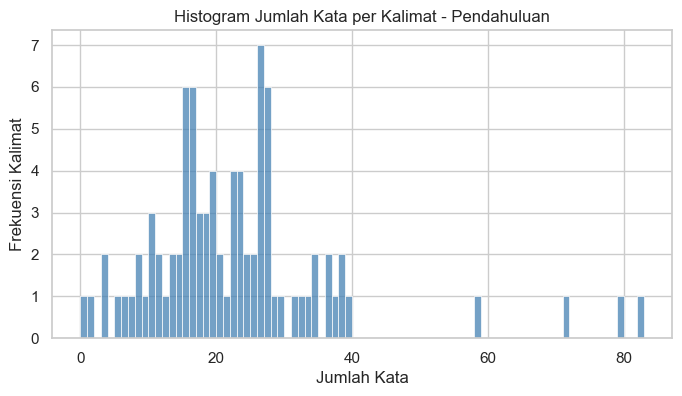


SOAL 4: Jumlah kalimat dalam setiap paragraf
Paragraf 1: 87 kalimat


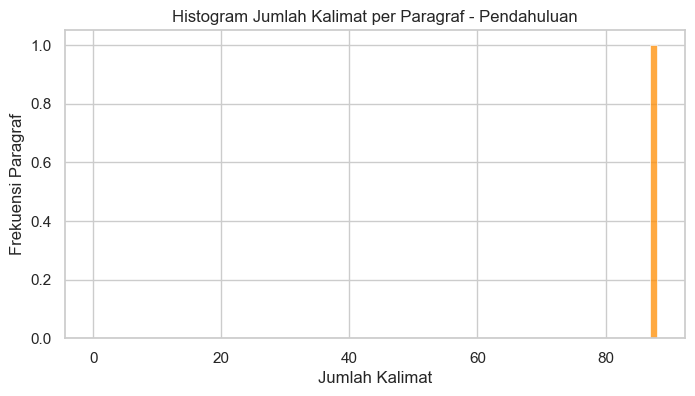

In [41]:
# ANALISIS PENDAHULUAN

bagian = pendahuluan
nama = "Pendahuluan"

print("\n" + "="*80)
print(f"CUPLIKAN ({nama}):")
print("-"*80)
print(bagian[:800] + ("..." if len(bagian)>800 else ""))
print("="*80 + "\n")

# SOAL 2: Pivot konsonan-vokal
print("SOAL 2: Tabel Pivot (frekuensi) & Tabel Pivot (kata unik)")
words = tokenize_words(bagian)
pairs = [count_vc(w) for w in words]
freq = Counter(pairs)
unique = defaultdict(set)
for w, vc in zip(words, pairs):
    unique[vc].add(w.lower())
unique_count = {k: len(s) for k, s in unique.items()}

if pairs:
    max_v = max(v for v,c in pairs)
    max_c = max(c for v,c in pairs)
else:
    max_v = max_c = 0

# build grids and labeled DataFrames
freq_grid = np.zeros((max_v+1, max_c+1), dtype=int)
uniq_grid = np.zeros((max_v+1, max_c+1), dtype=int)
for (v,c), f in freq.items():
    freq_grid[v,c] = f
for (v,c), u in unique_count.items():
    uniq_grid[v,c] = u

df_freq = pd.DataFrame(freq_grid, index=[f"v={i}" for i in range(max_v+1)],
                       columns=[f"c={j}" for j in range(max_c+1)])
df_uniq = pd.DataFrame(uniq_grid, index=[f"v={i}" for i in range(max_v+1)],
                       columns=[f"c={j}" for j in range(max_c+1)])

print("\nTabel Pivot Frekuensi (baris=vokal, kolom=konsonan):")
print(df_freq)
print("\nTabel Pivot Jumlah Kata Unik (baris=vokal, kolom=konsonan):")
print(df_uniq)

# Heatmaps
if df_freq.values.sum() > 0:
    plt.figure(figsize=(9,6))
    sns.heatmap(df_freq, annot=True, fmt="d", cmap="coolwarm", cbar_kws={'label':'Frekuensi'})
    plt.title(f"Heatmap Frekuensi Kata - {nama}")
    plt.xlabel("Jumlah Konsonan")
    plt.ylabel("Jumlah Vokal")
    plt.show()
else:
    print("Tidak ada frekuensi untuk diplot (tidak ada kata).")

if df_uniq.values.sum() > 0:
    plt.figure(figsize=(9,6))
    sns.heatmap(df_uniq, annot=True, fmt="d", cmap="crest", cbar_kws={'label':'Jumlah Kata Unik'})
    plt.title(f"Heatmap Kata Unik - {nama}")
    plt.xlabel("Jumlah Konsonan")
    plt.ylabel("Jumlah Vokal")
    plt.show()
else:
    print("Tidak ada data kata unik untuk diplot.")

# Ringkasan frekuensi + cacah
print("\nRingkasan (Soal 2):")
print(f"- Total kata (token) di {nama}: {len(words)}")
if freq:
    print("- Top kombinasi (vokal,konsonan) menurut frekuensi:")
    for (v,c),cnt in freq.most_common(6):
        print(f"   v={v}, c={c}  => frekuensi={cnt}, kata unik={unique_count.get((v,c),0)}")
else:
    print("- Tidak ada kata ditemukan.")

# SOAL 3: Jumlah kata dalam tiap kalimat 
print("\nSOAL 3: Jumlah kata dalam setiap kalimat")
sentences = split_sentences(bagian)
if sentences:
    words_per_sentence = [len(tokenize_words(s)) for s in sentences]
    for i, (s, wc) in enumerate(zip(sentences, words_per_sentence), start=1):
        print(f"Kalimat {i}: {wc} kata")
    # histogram overview
    plt.figure(figsize=(8,4))
    sns.histplot(words_per_sentence, bins=range(0, max(words_per_sentence)+2), kde=False, color="steelblue")
    plt.title(f"Histogram Jumlah Kata per Kalimat - {nama}")
    plt.xlabel("Jumlah Kata")
    plt.ylabel("Frekuensi Kalimat")
    plt.show()
else:
    print("Tidak ada kalimat terdeteksi pada bagian ini.")

# SOAL 4: Jumlah kalimat dalam tiap paragraf 
print("\nSOAL 4: Jumlah kalimat dalam setiap paragraf")
paragraphs = split_paragraphs(bagian)
if paragraphs:
    sentences_per_paragraph = [len(split_sentences(p)) for p in paragraphs]
    for i, sp in enumerate(sentences_per_paragraph, start=1):
        print(f"Paragraf {i}: {sp} kalimat")
    plt.figure(figsize=(8,4))
    sns.histplot(sentences_per_paragraph, bins=range(0, max(sentences_per_paragraph)+2), kde=False, color="darkorange")
    plt.title(f"Histogram Jumlah Kalimat per Paragraf - {nama}")
    plt.xlabel("Jumlah Kalimat")
    plt.ylabel("Frekuensi Paragraf")
    plt.show()
else:
    print("Tidak ada paragraf terdeteksi pada bagian ini.")


CUPLIKAN (Kesimpulan):
--------------------------------------------------------------------------------
Perkembangan Open Access di Indonesia sudah mulai menggeliat di berbagai institusikhususnya pada
institusi perguruan t inggi.Repositori institusi merupakan media yang telah berkembang lebih dulu sebagi
alat diseminasi karya ilmiah institusi. Munculnya pemeringkatan webometrik menjadi pemacu
perkembangan repository institusi di Indonesia. N amun perkembangannya kurang signifikan , nampak pada
rasio jumlah perguruan tinggi yang terindeks webometric.info dengan jumlah repository institusi .
Perkembangan yang cukup siginifikan terjadi pada tumbuh menjamurnya elektronik jurnal dalam berbagai
bidang ilmu milik perguruan tinggi yang dapat diakses secara terbuka.  Fenomena tersebut dipacu dengan
adanya undang -undang yang mengatur tentang publikasi karya ilmiah serta didukung dengan infrastruktur
...

SOAL 2: Tabel Pivot (frekuensi) & Tabel Pivot (kata unik)

Tabel Pivot Frekuensi (baris=vo

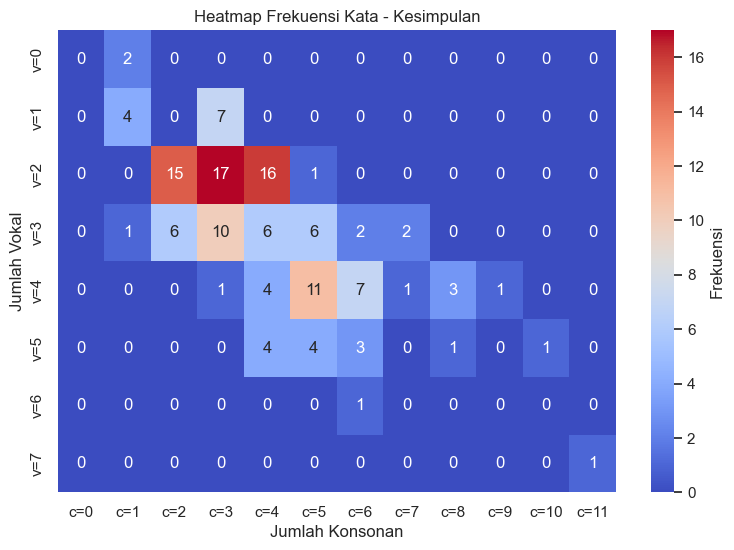

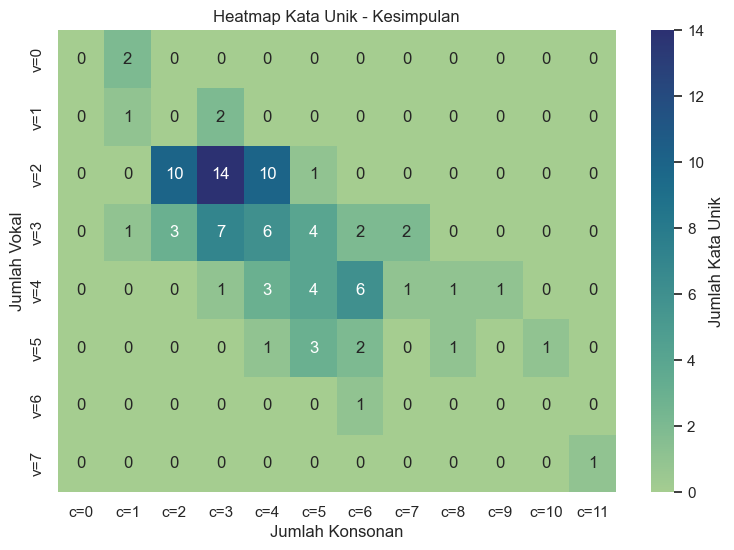


Ringkasan (Soal 2):
- Total kata (token) di Kesimpulan: 138
- Top kombinasi (vokal,konsonan) menurut frekuensi:
   v=2, c=3  => frekuensi=17, kata unik=14
   v=2, c=4  => frekuensi=16, kata unik=10
   v=2, c=2  => frekuensi=15, kata unik=10
   v=4, c=5  => frekuensi=11, kata unik=4
   v=3, c=3  => frekuensi=10, kata unik=7
   v=4, c=6  => frekuensi=7, kata unik=6

SOAL 3: Jumlah kata dalam setiap kalimat
Kalimat 1: 31 kata
Kalimat 2: 10 kata
Kalimat 3: 19 kata
Kalimat 4: 22 kata
Kalimat 5: 28 kata
Kalimat 6: 11 kata
Kalimat 7: 17 kata


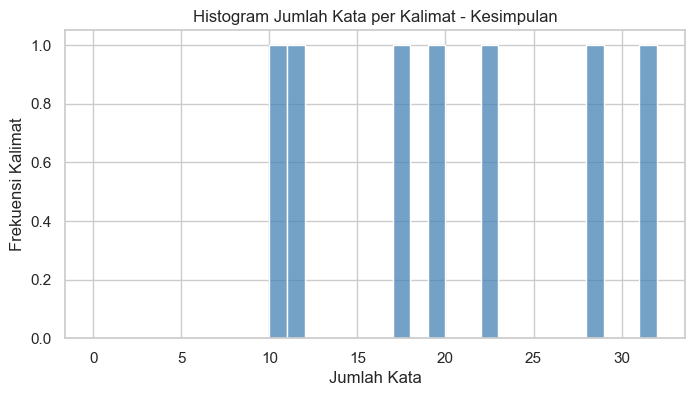


SOAL 4: Jumlah kalimat dalam setiap paragraf
Paragraf 1: 7 kalimat


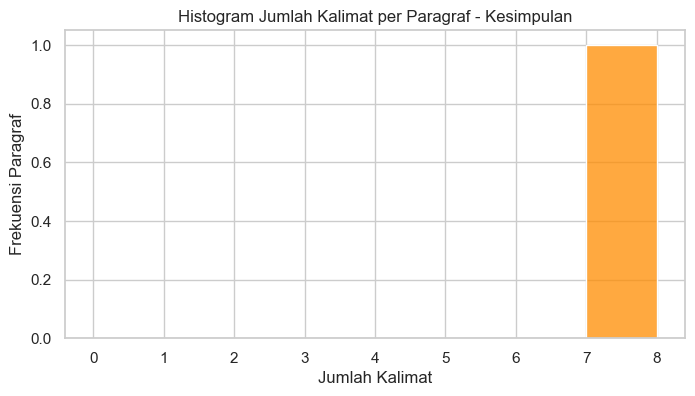

In [43]:
# ANALISIS KESIMPULAN

bagian = kesimpulan
nama = "Kesimpulan"

print("\n" + "="*80)
print(f"CUPLIKAN ({nama}):")
print("-"*80)
print(bagian[:800] + ("..." if len(bagian)>800 else ""))
print("="*80 + "\n")

# SOAL 2: Pivot konsonan-vokal
print("SOAL 2: Tabel Pivot (frekuensi) & Tabel Pivot (kata unik)")
words = tokenize_words(bagian)
pairs = [count_vc(w) for w in words]
freq = Counter(pairs)
unique = defaultdict(set)
for w, vc in zip(words, pairs):
    unique[vc].add(w.lower())
unique_count = {k: len(s) for k, s in unique.items()}

if pairs:
    max_v = max(v for v,c in pairs)
    max_c = max(c for v,c in pairs)
else:
    max_v = max_c = 0

# build grids and labeled DataFrames
freq_grid = np.zeros((max_v+1, max_c+1), dtype=int)
uniq_grid = np.zeros((max_v+1, max_c+1), dtype=int)
for (v,c), f in freq.items():
    freq_grid[v,c] = f
for (v,c), u in unique_count.items():
    uniq_grid[v,c] = u

df_freq = pd.DataFrame(freq_grid, index=[f"v={i}" for i in range(max_v+1)],
                       columns=[f"c={j}" for j in range(max_c+1)])
df_uniq = pd.DataFrame(uniq_grid, index=[f"v={i}" for i in range(max_v+1)],
                       columns=[f"c={j}" for j in range(max_c+1)])

print("\nTabel Pivot Frekuensi (baris=vokal, kolom=konsonan):")
print(df_freq)
print("\nTabel Pivot Jumlah Kata Unik (baris=vokal, kolom=konsonan):")
print(df_uniq)

# Heatmaps
if df_freq.values.sum() > 0:
    plt.figure(figsize=(9,6))
    sns.heatmap(df_freq, annot=True, fmt="d", cmap="coolwarm", cbar_kws={'label':'Frekuensi'})
    plt.title(f"Heatmap Frekuensi Kata - {nama}")
    plt.xlabel("Jumlah Konsonan")
    plt.ylabel("Jumlah Vokal")
    plt.show()
else:
    print("Tidak ada frekuensi untuk diplot (tidak ada kata).")

if df_uniq.values.sum() > 0:
    plt.figure(figsize=(9,6))
    sns.heatmap(df_uniq, annot=True, fmt="d", cmap="crest", cbar_kws={'label':'Jumlah Kata Unik'})
    plt.title(f"Heatmap Kata Unik - {nama}")
    plt.xlabel("Jumlah Konsonan")
    plt.ylabel("Jumlah Vokal")
    plt.show()
else:
    print("Tidak ada data kata unik untuk diplot.")

# Ringkasan frekuensi + cacah
print("\nRingkasan (Soal 2):")
print(f"- Total kata (token) di {nama}: {len(words)}")
if freq:
    print("- Top kombinasi (vokal,konsonan) menurut frekuensi:")
    for (v,c),cnt in freq.most_common(6):
        print(f"   v={v}, c={c}  => frekuensi={cnt}, kata unik={unique_count.get((v,c),0)}")
else:
    print("- Tidak ada kata ditemukan.")

# SOAL 3: Jumlah kata dalam tiap kalimat 
print("\nSOAL 3: Jumlah kata dalam setiap kalimat")
sentences = split_sentences(bagian)
if sentences:
    words_per_sentence = [len(tokenize_words(s)) for s in sentences]
    for i, (s, wc) in enumerate(zip(sentences, words_per_sentence), start=1):
        print(f"Kalimat {i}: {wc} kata")
    # histogram overview
    plt.figure(figsize=(8,4))
    sns.histplot(words_per_sentence, bins=range(0, max(words_per_sentence)+2), kde=False, color="steelblue")
    plt.title(f"Histogram Jumlah Kata per Kalimat - {nama}")
    plt.xlabel("Jumlah Kata")
    plt.ylabel("Frekuensi Kalimat")
    plt.show()
else:
    print("Tidak ada kalimat terdeteksi pada bagian ini.")

# SOAL 4: Jumlah kalimat dalam tiap paragraf 
print("\nSOAL 4: Jumlah kalimat dalam setiap paragraf")
paragraphs = split_paragraphs(bagian)
if paragraphs:
    sentences_per_paragraph = [len(split_sentences(p)) for p in paragraphs]
    for i, sp in enumerate(sentences_per_paragraph, start=1):
        print(f"Paragraf {i}: {sp} kalimat")
    plt.figure(figsize=(8,4))
    sns.histplot(sentences_per_paragraph, bins=range(0, max(sentences_per_paragraph)+2), kde=False, color="darkorange")
    plt.title(f"Histogram Jumlah Kalimat per Paragraf - {nama}")
    plt.xlabel("Jumlah Kalimat")
    plt.ylabel("Frekuensi Paragraf")
    plt.show()
else:
    print("Tidak ada paragraf terdeteksi pada bagian ini.")